# Teste de granularidade para modelos de ML

## carregando os dados

In [1]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import glob
import os

# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_day'
#tempo_dia = pd.read_csv('../../data/times/times_1_day.csv')
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
# 2. Use glob to get a list of all CSV files in the folder
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_dia = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_dia.append(df)

    #print(f"Loaded '{file}' as dataframe '{filename}'")

# --- Now you can access any dataframe by its filename ---
df_day = pd.concat(lista_dia, ignore_index=True)
del lista_dia
print("\n--- All dataframes loaded successfully! ---")


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_hour'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_hora = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_hora.append(df)
df_hour = pd.concat(lista_hora, ignore_index=True)
del lista_hora
# --- Now you can access any dataframe by its filename ---
print("\n--- All dataframes loaded successfully! ---")



# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_10_minutes'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_min = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = os.path.splitext(os.path.basename(file))[0]
    
    
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_min.append(df)

# --- Now you can access any dataframe by its filename ---
df_10min = pd.concat(lista_min, ignore_index=True)
del lista_min
print("\n--- All dataframes loaded successfully! ---")

1. Python is running from: /home/ismael/Documentos/Codigos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/Codigos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/Codigos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---


## Analise exploratória para redução de dados
Ao fazer a analise, entende-se que os dados possuem variancias bem distintas e escolhe-se alguns exemplares para fazer os experimentos



--- Seleção de instituições por intervalo de variância ---
Intervalo 1: 192 (variância: 1.8348942102102016e+17)
Intervalo 2: 249 (variância: 2.2758968479585403e+18)
Intervalo 3: 71 (variância: 4.068129251096789e+18)
Intervalo 4: 205 (variância: 8.673110997373813e+18)
Intervalo 5: 148 (variância: 1.3702997912693244e+19)
Intervalo 6: 184 (variância: 2.454075868335571e+19)
Intervalo 7: 125 (variância: 4.957993038562879e+19)
Intervalo 8: 164 (variância: 1.0616757614065536e+20)
Intervalo 9: 97 (variância: 4.637393479894093e+20)
Intervalo 10: 56 (variância: 1.276910105947984e+22)

Instituições selecionadas: ['192', '249', '71', '205', '148', '184', '125', '164', '97', '56']


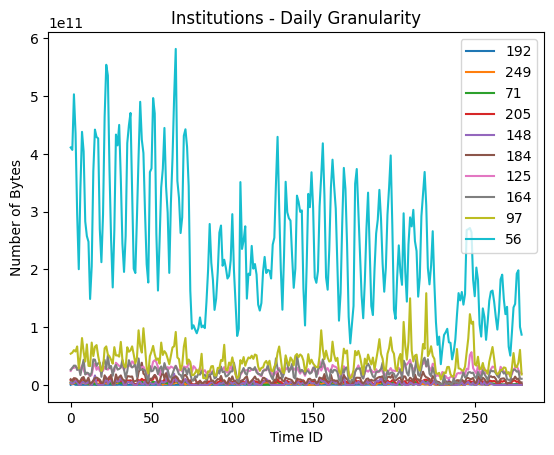

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random
import math
#analise dos dados diários
variancias = {}
for i in df_day["id_institution"].unique():
    instituicao = df_day[df_day["id_institution"]==i]
    serve = True

    #verifica se ha instituições com poucos dados e elimina elas se for o caso
    if instituicao.shape[0] < 50:
        #print(f"{i} tem poucos dados")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False

    #verifica se ha instituições com valores nulos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"].isnull()].shape[0]>0:
        #print(f"{i} tem valores nulos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False

    #verifica se ha instituições com variância zero e elimina elas se for o caso
    elif instituicao["n_bytes"].var() == 0:
        #print(f"{i} tem variância zero")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False

    #verifica se ha instituições com valores negativos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"]<0].shape[0]>0:
        #print(f"{i} tem valores negativos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False

    #verifica se ha instituições com outliers (valores muito altos) e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"] > instituicao["n_bytes"].mean() + 7*instituicao["n_bytes"].std()].shape[0]>0:
        #print(f"{i} tem outliers")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False


    if serve:
        variancias[i] = instituicao["n_bytes"].var()

# Ordena por variância crescente
variancias_ordenadas = sorted(variancias.items(), key=lambda x: x[1])

#print("Variâncias ordenadas:")
#for chave, valor in variancias_ordenadas:
#    print(f"{chave}: {valor}")

# Divide em 10 intervalos e seleciona a instituição da metade
num_intervalos = 10
num_instituicoes = len(variancias_ordenadas)
tamanho_intervalo = round(num_instituicoes / num_intervalos)

inst_filtradas = []
print("\n--- Seleção de instituições por intervalo de variância ---")
for i in range(num_intervalos):
    inicio = int(i * tamanho_intervalo)
    fim = int((i + 1) * tamanho_intervalo)
    intervalo = variancias_ordenadas[inicio:fim]
    
    
    inst_selecionada = intervalo[math.floor(tamanho_intervalo/2)][0]
    inst_filtradas.append(inst_selecionada)
    print(f"Intervalo {i+1}: {inst_selecionada} (variância: {np.float32(variancias[inst_selecionada])})")

print(f"\nInstituições selecionadas: {inst_filtradas}")
inst = inst_filtradas

for i in inst:
    instituicao = df_day[df_day["id_institution"]==i]
    
    plt.plot(instituicao["id_time"], instituicao["n_bytes"], label=i)
plt.title(f"Institutions - Daily Granularity")
plt.xlabel("Time ID")
plt.ylabel("Number of Bytes")
plt.legend()
plt.show()
    

In [9]:
from keras.models import Model
from keras.layers import Input, PReLU, Dense, LSTM, multiply, concatenate, Activation, GRU, SimpleRNN, Masking, Reshape
from keras.layers import AveragePooling1D,Flatten, Bidirectional,Conv1D, BatchNormalization, GlobalAveragePooling1D, Permute, Dropout, GlobalMaxPooling1D

# For Graphs plotting and training time evaluation
import pylab as plt
import time

TRAINABLE = True

#The proposed GRU-FCN model code
#GRU-FCN model
def generate_GRU_FCN_model(max_seq, output):
    inp = Input(shape=(1, max_seq))

    #GRU_part
    x_r = GRU(8)(inp) # GRU with 8 unrollments
    x_r = Dropout(0.8)(x_r) # 80% dropout

    #Convolutional_part
    y = Permute((2, 1))(inp)
    y = Conv1D(128, 8, padding='same', kernel_initializer='he_uniform')(y)#128
    y = BatchNormalization()(y)
    y = Activation('relu')(y)

    y = Conv1D(256, 5, padding='same', kernel_initializer='he_uniform')(y)#256
    y = BatchNormalization()(y)
    y = Activation('relu')(y)

    y = Conv1D(128, 3, padding='same', kernel_initializer='he_uniform')(y)#128
    y = BatchNormalization()(y)
    y = Activation('relu')(y)

    y = GlobalAveragePooling1D()(y)

    x = concatenate([x_r, y])

    out = Dense(output, activation='sigmoid')(x)

    model = Model(inp, out)

    model.summary()


import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
def treino_val_teste(df = pd.Series, t_treino = 0, t_teste = 0, t_val = 0):
    return  df[:int(t_treino*len(df))], df[int(t_treino*len(df)):int((t_treino + t_val)*len(df))]  , df[int((t_treino + t_val)*len(df)):]

       
    

def scaling(df_series: pd.Series, mode = 0, scaler = None) -> pd.Series:
    if mode == 0:
        scaler = MinMaxScaler()
        dados_reshaped = df_series.values.reshape(-1, 1)
        dados_scaled = scaler.fit_transform(dados_reshaped)
        return pd.Series(dados_scaled.flatten(), index=df_series.index, name=df_series.name),scaler
    elif mode == 1:
        dados_reshaped = df_series.values.reshape(-1, 1)
        dados_scaled = scaler.transform(dados_reshaped)
        return pd.Series(dados_scaled.flatten(), index=df_series.index, name=df_series.name)     

def sliding_window (df_series: pd.Series, inputs: int, outputs: int):

    total_window_size = inputs + outputs
    
    # 1. Validação
    if len(df_series) < total_window_size:
        print(f"Erro: Tamanho dos dados ({len(df_series)}) é menor que a janela total ({total_window_size})")
        return pd.DataFrame() # Retorna um DataFrame vazio

    # 2. Cria as janelas (sliding windows)
    windowed_data = []
    # Itera do primeiro índice inicial possível até o último
    for i in range(len(df_series) - total_window_size + 1):
        # A fatia vai de 'i' até 'i + tamanho_total'
        window_slice = df_series.iloc[i : i + total_window_size].values
        windowed_data.append(window_slice)

    # 3. Define os nomes das colunas
    x_cols = [f"x_{j}" for j in range(inputs)]
    y_cols = [f"y_{o}" for o in range(outputs)]
    
    # 4. Cria o DataFrame final
    df_windowed = pd.DataFrame(windowed_data, columns=x_cols + y_cols)
    
    return df_windowed

def generate_MLP_model(max_seq, output):
    ip = Input(shape=(max_seq,))
    
    y= Dropout(0.1)(ip)
    y = Flatten()(y)
    y = Dense(500, activation='relu')(y)
    y = Dropout(0.2)(y)
    y = Dense(500, activation='relu')(y)
    y = Dropout(0.2)(y)
    y = Dense(500, activation = 'relu')(y)
    y = Dropout(0.3)(y)
    out = Dense(output, activation='linear')(y)
    model = Model(ip, out)
    model.summary()
    return model

        
    
        
    

## Tratando [DIA] e separando em treino, val e teste

In [21]:
from sklearn.model_selection import train_test_split

inputs_day = 7
outputs_day = 1
x_cols = [f"x_{j}" for j in range(inputs_day)]
y_cols = [f"y_{o}" for o in range(outputs_day)]
train_list = []
val_list = []
test_list = []
#inst = inst_hour #SÓ DESCOMENTE ISSO DEPOIS DE TER RODADO A CELULA DE HORAS
for i in inst:
    print(i)
    serie = pd.Series(df_day[df_day["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_day + outputs_day):
        _train_day, _val_day, _test_day  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_day,scaler = scaling(_train_day,0)
        test_day = scaling(_test_day,1,scaler)
        val_day = scaling(_val_day,1,scaler)
        train_day_ = sliding_window(df_series = train_day, inputs = inputs_day, outputs = outputs_day)
        train_day_.insert(0, "id_institution", i)
        train_list.append(train_day_)

        test_day_ = sliding_window(df_series = test_day, inputs = inputs_day, outputs = outputs_day)
        test_day_.insert(0, "id_institution", i)
        test_list.append(test_day_)

        val_day_ = sliding_window(df_series = val_day, inputs = inputs_day, outputs = outputs_day)
        val_day_.insert(0, "id_institution", i)
        val_list.append(val_day_)

    else: print(f"   dataset pequeno ({tamanho})")
train_day_wind = pd.concat(train_list, ignore_index=True)
val_day_wind = pd.concat(val_list, ignore_index=True)
test_day_wind = pd.concat(test_list, ignore_index=True)
inst_day = list(train_day_wind["id_institution"].unique())
print("\n\n" + str(len(inst_day)))
del train_list, val_list, test_list
train_day_wind.to_csv('../../data/Tabelas_criadas/treino_dia.csv', index = False)
test_day_wind.to_csv('../../data/Tabelas_criadas/teste_dia.csv', index = False)
val_day_wind.to_csv('../../data/Tabelas_criadas/val_dia.csv', index = False)


192
249
71
205
148
184
125
164
97
56


10


## Tratando [HORAS] e separando em treino, val e teste

In [20]:
from sklearn.model_selection import train_test_split

inputs_hour = 7*24
outputs_hour = 1*24
x_cols = [f"x_{j}" for j in range(inputs_hour)]
y_cols = [f"y_{o}" for o in range(outputs_hour)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_hour[df_hour["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_hour + outputs_hour):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_hour,scaler = scaling(_train_hour,0)
        test_hour = scaling(_test_hour,1,scaler)
        val_hour = scaling(_val_hour,1,scaler)
        train_hour_ = sliding_window(df_series = train_hour, inputs = inputs_hour, outputs = outputs_hour)
        train_hour_.insert(0, "id_institution", i)
        train_list.append(train_hour_)

        test_hour_ = sliding_window(df_series = test_hour, inputs = inputs_hour, outputs = outputs_hour)
        test_hour_.insert(0, "id_institution", i)
        test_list.append(test_hour_)

        val_hour_ = sliding_window(df_series = val_hour, inputs = inputs_hour, outputs = outputs_hour)
        val_hour_.insert(0, "id_institution", i)
        val_list.append(val_hour_)
    else: print(f"   dataset pequeno ({tamanho})")

train_hour_wind = pd.concat(train_list, ignore_index=True)
val_hour_wind = pd.concat(val_list, ignore_index=True)
test_hour_wind = pd.concat(test_list, ignore_index=True)


train_hour_wind.to_csv('../../data/Tabelas_criadas/treino_hora.csv', index = False)
test_hour_wind.to_csv('../../data/Tabelas_criadas/teste_hora.csv', index = False)
val_hour_wind.to_csv('../../data/Tabelas_criadas/val_hora.csv', index = False)

192
249
71
205
148
184
125
164
97
56


KeyboardInterrupt: 

## Tratando [MINUTOS] e separando em treino, val e teste
por enquano, este vai ficar de escanteio por precisar de um tratamento mais especifico


In [ ]:
from sklearn.model_selection import train_test_split

inputs_10min = 2*24*6
outputs_10min = 1*24*6
x_cols = [f"x_{j}" for j in range(inputs_10min)]
y_cols = [f"y_{o}" for o in range(outputs_10min)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_10min[df_10min["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_10min + outputs_10min):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_10min,scaler = scaling(_train_hour,0)
        test_10min = scaling(_test_hour,1,scaler)
        val_10min = scaling(_val_hour,1,scaler)
        train_10min_ = sliding_window(df_series = train_10min, inputs = inputs_10min, outputs = outputs_10min)
        train_10min_["id_institution"] = i
        train_list.append(train_10min_)

        test_10min_ = sliding_window(df_series = test_10min, inputs = inputs_10min, outputs = outputs_10min)
        test_10min_["id_institution"] = i
        test_list.append(test_10min_)
        val_10min_ = sliding_window(df_series = val_10min, inputs = inputs_10min, outputs = outputs_10min)
        val_10min_["id_institution"] = i
        val_list.append(val_10min_)
    else: print(f"   dataset pequeno ({tamanho})")

train_10min_wind = pd.concat(train_list, ignore_index=True)
val_10min_wind = pd.concat(val_list, ignore_index=True)
test_10min_wind = pd.concat(test_list, ignore_index=True)
inst_10min = list(train_10min_wind["id_institution"].unique())
print("\n\n" + str(len(inst_10min)))


train_10min_wind.to_csv('../../data/Tabelas_criadas/treino_10min.csv', index = False)
test_10min_wind.to_csv('../../data/Tabelas_criadas/teste_10min.csv', index = False)
val_10min_wind.to_csv('../../data/Tabelas_criadas/val_10min.csv', index = False)

192
249
71
205
148
   dataset pequeno (0)
184
125
164
97
56


9


In [ ]:
train_day_wind = pd.read_csv('../../data/Tabelas_criadas/treino_dia.csv')
test_day_wind = pd.read_csv('../../data/Tabelas_criadas/teste_dia.csv')
val_day_wind = pd.read_csv('../../data/Tabelas_criadas/val_dia.csv')

In [26]:
np_train = np.array(train_hour_wind)
np_test = np.array(test_hour_wind)
np_val = np.array(val_hour_wind)
X_train = np_train[:, :inputs_day + 1].astype('float32')
y_train = np_train[:, inputs_day+1:].astype('float32')
X_test = np_test[:, :inputs_day + 1].astype('float32')
y_test = np_test[:, inputs_day+1:].astype('float32')
X_val = np_val[:, :inputs_day + 1].astype('float32')
y_val = np_val[:, inputs_day+1:].astype('float32')

MLP = generate_MLP_model(inputs_day+ 1, outputs_day)

from tensorflow.keras.metrics import RootMeanSquaredError
MLP.compile(
    optimizer='adam',
    loss='mean_squared_error', # Para regressão, a perda é o MSE
    metrics=[RootMeanSquaredError(name='rmse')]
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 500)            │         4,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 506,001 (1.93 MB)

 Trainable params: 506,001 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_hour_wind = pd.read_csv('../../data/Tabelas_criadas/treino_hora.csv')
test_hour_wind = pd.read_csv('../../data/Tabelas_criadas/teste_hora.csv')
val_hour_wind = pd.read_csv('../../data/Tabelas_criadas/val_hora.csv')

In [ ]:
np_train = np.array(train_hour_wind)
np_test = np.array(test_hour_wind)
np_val = np.array(val_hour_wind)
X_train = np_train[:, :inputs_hour + 1].astype('float32')
y_train = np_train[:, inputs_hour+1:].astype('float32')
X_test = np_test[:, :inputs_hour + 1].astype('float32')
y_test = np_test[:, inputs_hour+1:].astype('float32')
X_val = np_val[:, :inputs_hour + 1].astype('float32')
y_val = np_val[:, inputs_hour+1:].astype('float32')

MLP = generate_MLP_model(inputs_hour+ 1, outputs_hour)

from tensorflow.keras.metrics import RootMeanSquaredError
MLP.compile(
    optimizer='adam',
    loss='mean_squared_error', # Para regressão, a perda é o MSE
    metrics=[RootMeanSquaredError(name='rmse')]
)


2026-02-03 12:06:19.560117: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 169)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 169)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 169)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │        85,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │        12,024 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598,024 (2.28 MB)

 Trainable params: 598,024 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = MLP.fit(
    X_train, 
    y_train, 
    epochs=20, # Comece com poucas epochs (ex: 10) e aumente se necessário
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1 # Mostra a barra de progresso
)

print("\n--- Treinamento Concluído ---")

# 'history' agora contém um registro do 'loss' e 'accuracy' de cada epoch
print("\nAcurácia final de validação:")
print(history.history['rmse'][-1])

Epoch 1/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.1212 - rmse: 1.0589 - val_loss: 0.0080 - val_rmse: 0.0897
Epoch 2/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0116 - rmse: 0.1075 - val_loss: 0.0074 - val_rmse: 0.0860
Epoch 3/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0086 - rmse: 0.0926 - val_loss: 0.0072 - val_rmse: 0.0847
Epoch 4/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0078 - rmse: 0.0885 - val_loss: 0.0073 - val_rmse: 0.0857
Epoch 5/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0076 - rmse: 0.0874 - val_loss: 0.0075 - val_rmse: 0.0865
Epoch 6/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0076 - rmse: 0.0872 - val_loss: 0.0073 - val_rmse: 0.0857
Epoch 7/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0076 - rmse: 0.0869 - val_loss: 0.0072 - val_rmse: 0.0851
Epoch 8/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0075 - rmse: 0.0864 - val_loss: 0.0075 - val_rmse: 0.0867
Epoch 9/20
1200/1200 ━━━

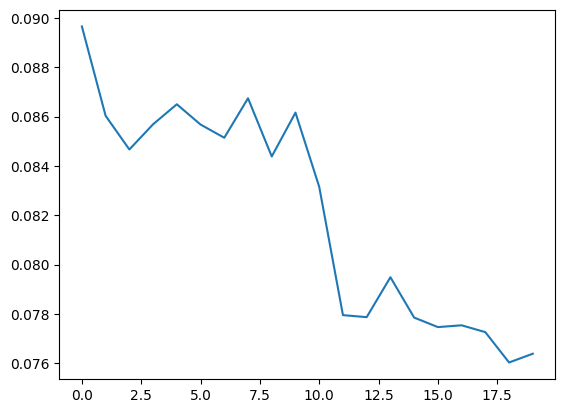

In [28]:
plt.plot(history.history['val_rmse'])

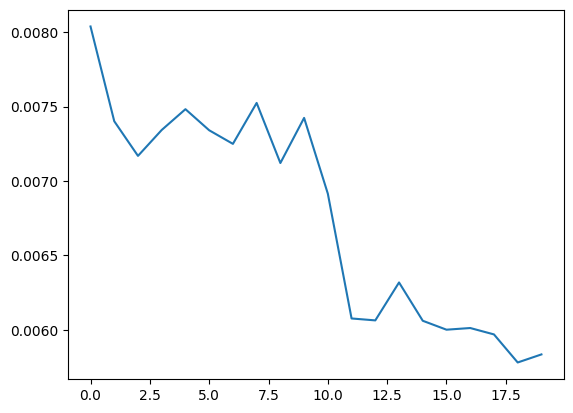

In [29]:
plt.plot(history.history['val_loss'])

In [30]:
MLP.save("../../MODELOS/MLP_dias.keras")
dict_models = {"MODELO": "MLP" , "DIM": "DIAS", "RMSE": history.history['val_rmse'][-1]}
df_models = pd.DataFrame([dict_models])
header_condition = not os.path.exists("../../MODELOS/modelos_treinados.csv")
df_models.to_csv("../../MODELOS/modelos_treinados.csv", index = False, mode='a', header=header_condition)


In [ ]:
MLP.save("../../MODELOS/MLP_horas.keras")
dict_models = {"MODELO": "MLP" , "DIM": "HORAS", "RMSE": history.history['val_rmse'][-1]}
df_models = pd.DataFrame([dict_models])
header_condition = not os.path.exists("../../MODELOS/modelos_treinados.csv")
df_models.to_csv("../../MODELOS/modelos_treinados.csv", index = False, mode='a', header=header_condition)

In [ ]:
y_ = MLP.predict(X_test)
display(pd.merge(pd.DataFrame(X_test), pd.DataFrame(y_test), left_index=True, right_index=True))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,0_x,1,2,3,4,5,6,7,0_y
0,192.0,0.175780,0.271555,0.306876,0.152543,0.112644,0.093794,0.192060,0.153840
1,192.0,0.271555,0.306876,0.152543,0.112644,0.093794,0.192060,0.153840,0.207778
2,192.0,0.306876,0.152543,0.112644,0.093794,0.192060,0.153840,0.207778,0.217757
3,192.0,0.152543,0.112644,0.093794,0.192060,0.153840,0.207778,0.217757,0.242740
4,192.0,0.112644,0.093794,0.192060,0.153840,0.207778,0.217757,0.242740,0.212215
...,...,...,...,...,...,...,...,...,...
765,56.0,0.149270,0.123779,0.153152,0.109115,0.146112,0.369031,0.371976,0.376094
766,56.0,0.123779,0.153152,0.109115,0.146112,0.369031,0.371976,0.376094,0.360984
767,56.0,0.153152,0.109115,0.146112,0.369031,0.371976,0.376094,0.360984,0.195568
768,56.0,0.109115,0.146112,0.369031,0.371976,0.376094,0.360984,0.195568,0.138363
